In [3]:
# Colab necessary packages installation
!pip install torch_geometric
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [4]:
# Colab import google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# imports
import torch
import json
import pandas as pd
from torch_geometric.data.hetero_data import HeteroData
from torch_geometric.loader import DataLoader
from torch.nn import ModuleList, Module, Linear, ModuleDict
from torch_geometric.nn import HeteroConv, GATv2Conv, global_mean_pool
from typing_extensions import Self

In [6]:
# Default vars
DATASET         = "BPI20_RequestForPayment"

ROOT_PATH       = "drive/MyDrive/Thesis"
PROCESSED_PATH  = f"{ROOT_PATH}/data/datasets/processed/{DATASET}"
MODEL_PATH      = f"{ROOT_PATH}/data/datasets/models/{DATASET}"
GRAPHS_PATH     = f"{ROOT_PATH}/data/datasets/graphs/{DATASET}"
MIN_PREFIX_LEN  = 2
BATCH_SIZE      = 128

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

config = {
    "hid": 128,
    "layers": 2,
    "aggregation": "max",
}

In [7]:
# Set up
with open(f"{ROOT_PATH}/data/dataset_features.json") as f:
    dataset_info = json.load(f)[DATASET]

tab_all = pd.read_csv(f"{PROCESSED_PATH}/{DATASET}_processed_all.csv")

categorical_columns = dataset_info["categorical"]
categorical_columns = [col for col in categorical_columns if col in tab_all.columns]
real_value_columns = dataset_info["numerical"]

list_unique = {k : list(tab_all[k].unique()) for k in categorical_columns}

idx_to_activity = {i: name for i, name in enumerate(list_unique["Activity"])} # Index-activity map

In [8]:
# Model definition (SEPHIGRAPH)
class HGNN(Module):
    def __init__(self, output_cat, output_real, nodes_relations, parameters) -> Self:
        super().__init__()
        hid         = parameters["hid"]
        layers      = parameters["layers"]
        aggregation = parameters["aggregation"]
        self.output_cat  = output_cat
        self.output_real = output_real
        self.convs = ModuleList()
        for _ in range(layers):
            conv = HeteroConv(
                {
                    relation: GATv2Conv(
                        (-1, -1), hid, 1, False,
                        add_self_loops=False, residual=False
                    )
                    for relation in nodes_relations
                },
                aggr=aggregation,
            )
            self.convs.append(conv)
        self.FC = ModuleDict()
        for k in output_cat:
            self.FC[k] = Linear(hid, output_cat[k])
        for k in output_real:
            self.FC[k] = Linear(hid, 1)

    def forward(self, batch):
        for conv in self.convs:
            batch.x_dict = conv(batch.x_dict, batch.edge_index_dict)
            batch.x_dict = {k: x.relu() for k, x in batch.x_dict.items()}
        output = {}
        for k in self.output_cat:
            output[k] = global_mean_pool(batch.x_dict[k], batch[k].batch)
            output[k] = self.FC[k](output[k])
        for k in self.output_real:
            output[k] = global_mean_pool(batch.x_dict[k], batch[k].batch)
            output[k] = self.FC[k](output[k]).reshape(1, -1)[0]
        return output

In [9]:
# Test prefixes load
torch.serialization.add_safe_globals([HeteroData]) # "marks the HeteroData class as safe for weights_only loading in torch.load"
X_TEST_FULL = torch.load(
    f"{GRAPHS_PATH}/test_set.pt",
    weights_only=False,
    map_location=device
)

X_TEST = [
    g for g in X_TEST_FULL
    if g["Activity"].x.shape[0] >= MIN_PREFIX_LEN
]

print(f"Grafi nel test set totale:   {len(X_TEST_FULL)}")
print(f"Grafi con prefisso > {MIN_PREFIX_LEN}:      {len(X_TEST)}")

Grafi nel test set totale:   4751
Grafi con prefisso > 2:      4751


In [10]:
# Get edge_types
edge_types = set()
for g in X_TEST:
    _, et = g.metadata()
    edge_types.update(et)
EDGE_TYPES = list(edge_types)

outputcat  = {k: len(list_unique[k]) for k in categorical_columns if k.startswith(("org:", "Activity"))}
outputreal = [k for k in real_value_columns if k.startswith("time:")]

print(outputcat)
print(outputreal)

{'org:resource': 2, 'Activity': 19, 'org:role': 8}
['time:timestamp']


In [11]:
# Define net model
net = HGNN(
    parameters=config,
    output_cat=outputcat,
    output_real=outputreal,
    nodes_relations=EDGE_TYPES,
)

net.load_state_dict(torch.load(f"{MODEL_PATH}/model.pt", map_location=device, weights_only=False), strict=False)
net = net.to(device)


In [12]:
# First graph dissection
g = X_TEST[6]
print(g)

HeteroData(
  y={
    Activity=[1],
    time:timestamp=[1],
    org:resource=[1],
    org:role=[1],
    case:Project=[1],
    case:Task=[1],
    case:OrganizationalEntity=[1],
    case:RequestedAmount=[1],
    case:Activity=[1],
    case:RfpNumber=[1],
  },
  Activity={ x=[2, 19] },
  time:timestamp={ x=[2, 1] },
  org:resource={ x=[2, 2] },
  org:role={ x=[2, 8] },
  case:Project={ x=[1, 79] },
  case:Task={ x=[1, 597] },
  case:OrganizationalEntity={ x=[1, 36] },
  case:RequestedAmount={ x=[1, 1] },
  case:Activity={ x=[1, 6] },
  case:RfpNumber={ x=[1, 6322] },
  (Activity, followed_by, Activity)={ edge_index=[2, 2] },
  (Activity, related_to, time:timestamp)={ edge_index=[2, 2] },
  (Activity, related_to, org:resource)={ edge_index=[2, 2] },
  (Activity, related_to, org:role)={ edge_index=[2, 2] },
  (Activity, related_to, case:Project)={ edge_index=[2, 2] },
  (Activity, related_to, case:Task)={ edge_index=[2, 2] },
  (Activity, related_to, case:OrganizationalEntity)={ edge_index=

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

import networkx as nx
import matplotlib.pyplot as plt

def get_row(ntype):
    if ntype == "Activity":
        return 1
    elif ntype == "time:timestamp":
        return 2
    elif ntype.startswith("org:"):
        return 3
    else:
        return 0

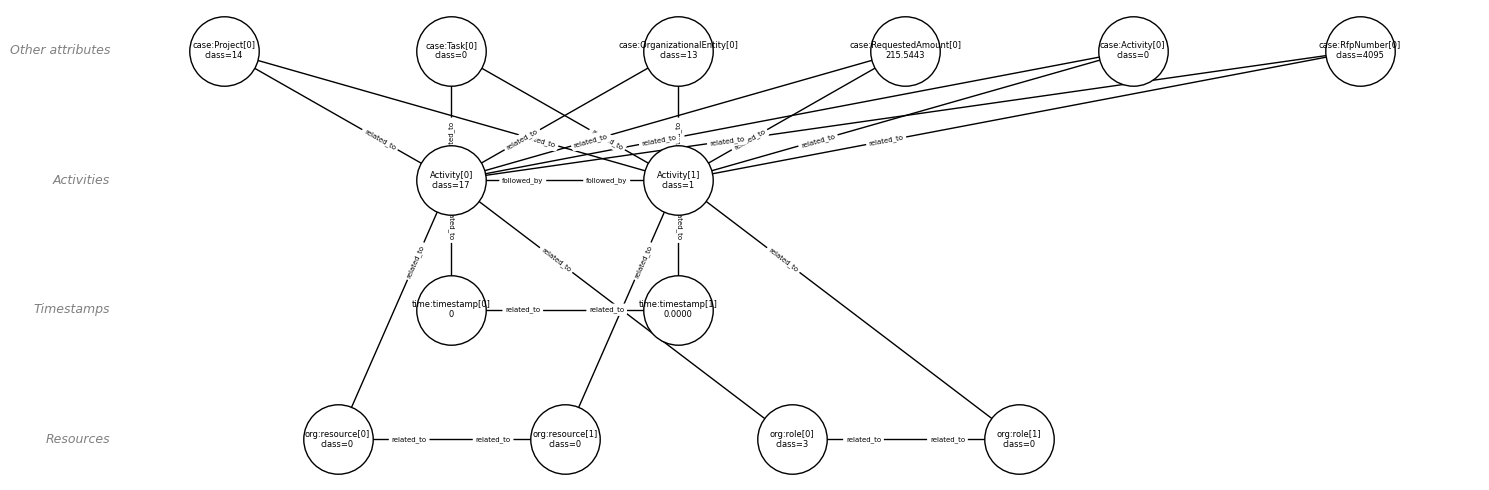

In [14]:
def drawer(g_original):
    g = g_original.clone()
    G = nx.Graph()

    node_id = {}
    node_label = {}
    edge_label = {}
    counter = 0

    import torch

    def format_features(x_row):
        t = torch.tensor(x_row) if not isinstance(x_row, torch.Tensor) else x_row
        # one-hot: un solo 1, resto 0
        if t.sum() == 1.0 and ((t == 0) | (t == 1)).all():
            return f"class={t.argmax().item()}"
        # scalare singolo
        if t.numel() == 1:
            v = t.item()
            return str(int(v)) if float(v).is_integer() else f"{v:.4f}"
        # vettore multi-feature
        parts = []
        for v in t.tolist():
            parts.append(str(int(v)) if float(v).is_integer() else f"{v:.3f}")
        return ", ".join(parts)

    for ntype in g.node_types:
        n = g[ntype].x.shape[0]
        for i in range(n):
            nid = counter
            node_id[(ntype, i)] = nid
            vals = g[ntype].x[i].tolist()
            vals_str = format_features(g[ntype].x[i])
            node_label[nid] = f"{ntype}[{i}]\n{vals_str}"
            G.add_node(nid)
            counter += 1

    for (src_type, rel, dst_type) in g.edge_types:
        if rel.startswith("rev_"):
            continue
        edge_index = g[(src_type, rel, dst_type)].edge_index
        for j in range(edge_index.shape[1]):
            src = node_id[(src_type, edge_index[0, j].item())]
            dst = node_id[(dst_type, edge_index[1, j].item())]
            if src != dst:
                G.add_edge(src, dst)
                edge_label[(src, dst)] = rel

    # --- custom row layout ---
    row_counters = {0: 0, 1: 0, 2: 0, 3: 0}
    row_counts = {0: 0, 1: 0, 2: 0, 3: 0}
    for ntype in g.node_types:
        row_counts[get_row(ntype)] += g[ntype].x.shape[0]

    pos = {}
    for (ntype, i), nid in node_id.items():
        row = get_row(ntype)
        col = row_counters[row]
        total = row_counts[row]
        # center nodes horizontally within each row
        x = (col*1) + col - (total - 1) / 2.0
        y = -row * 6.0
        pos[nid] = (x, y)
        row_counters[row] += 1

    row_labels = {0: "Other attributes", 1: "Activities", 2: "Timestamps", 3: "Resources"}
    x_min = min(p[0] for p in pos.values()) - 1

    fig, ax = plt.subplots(figsize=(15, 5))
    nx.draw(G, pos, labels=node_label, with_labels=True,
            node_size=2500, font_size=6, node_color="white",
            edgecolors="black", linewidths=1.0, ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_label,
                              font_size=5, label_pos=0.3, ax=ax)

    for row, label in row_labels.items():
        ax.text(x_min, -row * 6.0, label, fontsize=9,
                va="center", ha="right", color="gray", style="italic")

    plt.tight_layout()
    plt.show()

drawer(g)

In [15]:
def print_edges(g):
  print("\nEdges List:")
  for (src_type, rel, dst_type), edge_store in g.edge_items():
      if rel.startswith("rev_"):
          continue
      print(f"({src_type}, {rel}, {dst_type})")
      print(edge_store.edge_index)
      print()

print_edges(g)


Edges List:
(Activity, followed_by, Activity)
tensor([[0, 1],
        [1, 0]])

(Activity, related_to, time:timestamp)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, org:resource)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, org:role)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, case:Project)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:Task)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:OrganizationalEntity)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:RequestedAmount)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:Activity)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:RfpNumber)
tensor([[0, 1],
        [0, 0]])

(time:timestamp, related_to, time:timestamp)
tensor([[0, 1],
        [1, 0]])

(org:resource, related_to, org:resource)
tensor([[0, 1],
        [1, 0]])

(org:role, related_to, org:role)
tensor([[0, 1],
        [1, 0]])



In [16]:
loader = DataLoader([g], batch_size=1)
batch = next(iter(loader))  # ora batch[k].batch esiste

net.eval()
with torch.no_grad():
    out = net(batch)

print(out)

{'org:resource': tensor([[37.6076, -5.7974]]), 'Activity': tensor([[  21.9347,   17.9528,   11.7559,   -7.5422,   15.5884, -196.2946,
           29.1802,   22.8199,  -55.7696, -199.4866,   16.8130,  -37.7430,
           54.1814,    2.8232,  -87.9004,   13.1880, -100.5701,   31.5467,
           -3.0341]]), 'org:role': tensor([[ 56.7364,  46.2284, -36.5172,  74.8893,  42.4920,  46.2646,  49.0200,
          40.8991]]), 'time:timestamp': tensor([0.6170])}


In [17]:
# Prediction extraction
preds = {}

# Categoriche → argmax → one-hot
for k in outputcat:
    idx = torch.argmax(torch.softmax(out[k], dim=1), dim=1).item()
    one_hot = torch.zeros(1, outputcat[k])
    one_hot[0, idx] = 1.0
    preds[k] = one_hot
    print(f"{k}: {list_unique[k][idx]}")

# Numeriche → valore diretto
for k in outputreal:
    preds[k] = out[k].reshape(1, 1)
    print(f"{k}: {out[k].item():.4f}")

org:resource: STAFF MEMBER
Activity: Request For Payment REJECTED by ADMINISTRATION
org:role: PRE_APPROVER
time:timestamp: 0.6170


In [18]:
for k in preds:
    print(f"{k}: grafo={g[k].x.shape[1]}, pred={preds[k].shape[1]}")

org:resource: grafo=2, pred=2
Activity: grafo=19, pred=19
org:role: grafo=8, pred=8
time:timestamp: grafo=1, pred=1


In [19]:
predicted_types = set(outputcat.keys()) | set(outputreal)

predicted_types

{'Activity', 'org:resource', 'org:role', 'time:timestamp'}

In [20]:
other_types = set(g.node_types) - predicted_types

other_types

{'case:Activity',
 'case:OrganizationalEntity',
 'case:Project',
 'case:RequestedAmount',
 'case:RfpNumber',
 'case:Task'}

In [21]:
resource_types = {ntype for ntype in g.node_types if ntype.startswith("org:")}

resource_types

{'org:resource', 'org:role'}

In [22]:
def to_onehot(logits, n_classes):
    idx = torch.argmax(torch.softmax(logits, dim=1), dim=1).item()
    oh = torch.zeros(1, n_classes)
    oh[0, idx] = 1.0
    return oh

def add_edge(g, rel, src, dst):
  new_e = torch.tensor([[src], [dst]])
  if hasattr(g[rel], 'edge_index') and g[rel].edge_index is not None:
      g[rel].edge_index = torch.cat([g[rel].edge_index, new_e], dim=1)
  else:
      g[rel].edge_index = new_e

def find_node_index(g, ntype, predicted_tensor):
    """Trova l'indice del nodo di tipo ntype che ha lo stesso argmax del tensore predetto."""
    argmax_pred = predicted_tensor.argmax().item()
    for i in range(g[ntype].x.shape[0]):
        if g[ntype].x[i].argmax().item() == argmax_pred:
            return i
    return None  # non trovato — non dovrebbe succedere

In [23]:
print(g.edge_types)

[('Activity', 'followed_by', 'Activity'), ('Activity', 'related_to', 'time:timestamp'), ('Activity', 'related_to', 'org:resource'), ('Activity', 'related_to', 'org:role'), ('Activity', 'related_to', 'case:Project'), ('Activity', 'related_to', 'case:Task'), ('Activity', 'related_to', 'case:OrganizationalEntity'), ('Activity', 'related_to', 'case:RequestedAmount'), ('Activity', 'related_to', 'case:Activity'), ('Activity', 'related_to', 'case:RfpNumber'), ('time:timestamp', 'related_to', 'time:timestamp'), ('org:resource', 'related_to', 'org:resource'), ('org:role', 'related_to', 'org:role'), ('time:timestamp', 'rev_related_to', 'Activity'), ('org:resource', 'rev_related_to', 'Activity'), ('org:role', 'rev_related_to', 'Activity'), ('case:Project', 'rev_related_to', 'Activity'), ('case:Task', 'rev_related_to', 'Activity'), ('case:OrganizationalEntity', 'rev_related_to', 'Activity'), ('case:RequestedAmount', 'rev_related_to', 'Activity'), ('case:Activity', 'rev_related_to', 'Activity'), ('

In [24]:
def append_predicted_event(g, out, outputcat, outputreal):

  old_idx = {}   # indici dei nodi a cui appendere l'output
  new_idx = {}   # indici dei nodi da appendere

  old_idx = {ntype: g[ntype].x.shape[0] - 1 for ntype in g.node_types}  # snapshot iniziale

  print_edges(g)

  for k in outputcat:
      new_feat = to_onehot(out[k], outputcat[k])

      if k in resource_types:
          existing = find_node_index(g, k, new_feat)
          if existing is not None:
              new_idx[k] = existing  # riusato
          else:
              g[k].x = torch.cat([g[k].x, new_feat], dim=0)
              new_idx[k] = old_idx[k] + 1 # appena creato
      else:
          g[k].x = torch.cat([g[k].x, new_feat], dim=0)
          new_idx[k] = old_idx[k] + 1

  for k in outputreal:
      new_feat = out[k].reshape(1, 1)

      if k in resource_types:
          existing = find_node_index(g, k, new_feat)
          if existing is not None:
              new_idx[k] = existing  # riusato
          else:
              g[k].x = torch.cat([g[k].x, new_feat], dim=0)
              new_idx[k] = old_idx[k] + 1  # appena creato
      else:
          g[k].x = torch.cat([g[k].x, new_feat], dim=0)
          new_idx[k] = old_idx[k] + 1

  # --- ricava gli archi da aggiungere dalla struttura esistente ---
  for (src, rel, dst) in g.edge_types:

      # Concateno predizioni
      if src == dst and src in predicted_types:
          if new_idx[src] == old_idx[src] + 1:
              add_edge(g, (src, rel, dst), old_idx[src], new_idx[src])

      # Activity → attributo predetto
      elif src == "Activity" and dst in predicted_types:
          add_edge(g, (src, rel, dst), new_idx[src], new_idx[dst])

      # Activity → costante
      elif src == "Activity" and dst not in predicted_types:
          add_edge(g, (src, rel, dst), new_idx[src], 0)

  print_edges(g)


  return g

In [25]:
newg = append_predicted_event(g, out, outputcat, outputreal)


Edges List:
(Activity, followed_by, Activity)
tensor([[0, 1],
        [1, 0]])

(Activity, related_to, time:timestamp)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, org:resource)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, org:role)
tensor([[0, 1],
        [0, 1]])

(Activity, related_to, case:Project)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:Task)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:OrganizationalEntity)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:RequestedAmount)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:Activity)
tensor([[0, 1],
        [0, 0]])

(Activity, related_to, case:RfpNumber)
tensor([[0, 1],
        [0, 0]])

(time:timestamp, related_to, time:timestamp)
tensor([[0, 1],
        [1, 0]])

(org:resource, related_to, org:resource)
tensor([[0, 1],
        [1, 0]])

(org:role, related_to, org:role)
tensor([[0, 1],
        [1, 0]])


Edges List:
(Activity, followed_by, Act

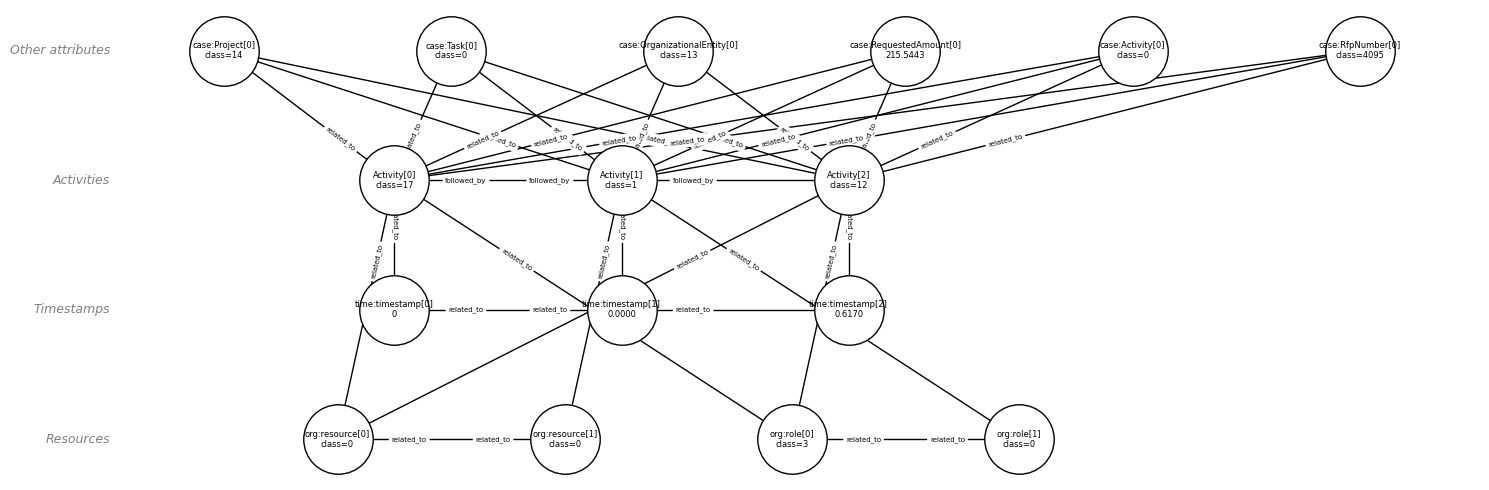

In [26]:
drawer(newg)